### Notebook overview
This notebook reproduces an **unconditional (baseline)** forecast for a single macroeconomic time series using **BISTRO** (BIS Time-series Regression Oracle), as described in the accompanying paper.

- **Task**: forecast US CPI inflation (year-over-year), monthly, with no covariates.
- **Workflow**: choose the forecast horizon (PDT) and history length (CTX), run a rolling-origin backtest, and collect probabilistic forecasts (median and uncertainty bands).
- **Outputs**: a window-by-window forecast table and an overlay plot of forecasts versus the realised series.

### Data
- Source: BIS CPI statistics (US CPI, YoY; monthly).
- More CPI series: see `data/`.


### Step 1 - Setup
- Make the project code in `src/` available to the notebook.
- Import the required libraries and helper functions.


### Google Colab users
- Colab may preinstall **NumPy 2.x**.
- After the downgrade runs, it triggers an automatic restart by terminating the current process.


In [1]:
import os
import subprocess

try:
    import numpy as np
    if np.__version__.startswith('2.'):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        # 2. Install the 1.x stack and compatible dependencies to stop the red errors
        # We include specific versions of pandas/scipy that like NumPy 1.x
        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ])

        print("✅ Install complete. Restarting runtime automatically...")

        # 3. Kill the process to force a reload of the new (older) library
        os.kill(os.getpid(), 9)
    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")
except ImportWarning:
    pass

✅ Success! Using NumPy version: 1.26.4


In [12]:
import os
import shutil
import sys

# 1. 경로 및 저장소 설정
repo_name = "BOK_BISTRO"
repo_url = f"https://github.com/choigahyun0920/{repo_name}.git"

# 2. 안전한 초기 위치(/content)로 이동
os.chdir('/content')

# 3. "강제 삭제 및 재클론": 폴더가 꼬였을 때 가장 확실한 방법입니다.
if os.path.exists(repo_name):
    print(f"♻️ 기존 {repo_name} 폴더를 삭제하고 초기화합니다...")
    shutil.rmtree(repo_name)

print(f"🚀 저장소 클론 중: {repo_url}")
!git clone -q {repo_url}

# 4. 폴더 안으로 이동 및 확인
if os.path.exists(repo_name):
    os.chdir(repo_name)
    print(f"✅ 현재 위치: {os.getcwd()}")

    # BISTRO 모듈(inference_util 등)을 불러오기 위해 src 폴더 등록
    src_path = os.path.abspath('src')
    if src_path not in sys.path:
        sys.path.append(src_path)
        print(f"📍 시스템 경로에 '{src_path}' 추가 완료.")
else:
    print("❌ 폴더를 찾을 수 없습니다. 저장소 이름을 다시 확인해주세요.")

# 5. 필수 라이브러리 설치 (NumPy 1.26.4 고정)
try:
    import uni2ts
    print("✅ 이미 모든 라이브러리가 설치되어 있습니다.")
except ImportError:
    print("📦 필수 패키지 설치를 시작합니다...")
    !pip install -q numpy==1.26.4
    !pip install -q -r requirements.txt
    print("✨ 환경 구축 완료!")

🚀 저장소 클론 중: https://github.com/choigahyun0920/BOK_BISTRO.git
✅ 현재 위치: /content/BOK_BISTRO
📍 시스템 경로에 '/content/BOK_BISTRO/src' 추가 완료.
✅ 이미 모든 라이브러리가 설치되어 있습니다.


### Restart Colab to finish setup

To make sure the newly installed packages load correctly, please restart the runtime:

**Runtime → Restart session**

After it restarts, continue by running the next cells below.

In [14]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
  os.chdir('/content/BOK_BISTRO/script')

repo_root = Path(os.path.join('..')).resolve()
src_root = Path(os.path.join('..', 'src')).resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


In [15]:
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
)


### Step 2 - Data and settings
- Set the forecast horizon (PDT) and how much history the model reads (CTX).


In [37]:
MODEL_REPO = repo_root / 'bistro-finetuned'

FREQ = 'M'  # monthly data frequency

PDT = 12   # how many months to forecast ahead
CTX = 100 # how many months of past data the model reads
PSZ = 32  # patch size used by the model (kept as default for this setup)
BSZ = 32  # batch size for faster forecasting
ROLLING_WINDOWS = 4  # how many starting points to evaluate
WINDOW_DISTANCE = 2  # gap (in months) between those starting points

FORECAST_START_DATE = '2018-01-01'

config = {
    "MODEL_REPO": str(MODEL_REPO),
    "PDT": PDT,
    "CTX": CTX,
    "PSZ": PSZ,
    "BSZ": BSZ,
    "ROLLING_WINDOWS": ROLLING_WINDOWS,
    "WINDOW_DISTANCE": WINDOW_DISTANCE,
    "FORECAST_START_DATE": FORECAST_START_DATE,
}


- Load the CPI series and construct rolling test windows.

In [38]:
series1 = repo_root / 'data' / 'inf.csv'

df = pd.read_csv(series1, index_col=0)
df.index = pd.to_datetime(df.index).to_period(freq=FREQ)

target_col = df.columns[0]

prep = prepare_yoy_monthly_for_daily_inference(
    df,
    target_col=target_col,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

if prep.windows < 1:
    raise ValueError(
        f'Not enough test data after cutoff {prep.train_end} to create a window: '
        f'test_len={(prep.df_yoy_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}.'
    )

ds = PandasDataset(prep.daily_df, target=target_col)
train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=prep.windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)


### Step 3 - Run BISTRO
- Load the pretrained BISTRO checkpoint.
- Generate probabilistic forecasts for each window.


In [39]:
from pathlib import Path
import os

# 1. 모델이 들어있는 폴더 경로를 'bistro'라는 변수에 저장
# (코랩 환경이라면 /content/BOK_BISTRO/bistro-finetuned 경로가 됩니다)
bistro = Path('/content/bistro/bistro-finetuned')

# 2. 모델 로드 시 MODEL_REPO 대신 bistro 변수 사용
try:
    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(str(bistro)), # 여기서 bistro 사용!
        prediction_length=int(prep.pdt_steps),
        context_length=int(prep.ctx_steps),
        patch_size=int(PSZ),
        num_samples=int(config.get("NUM_SAMPLES", 100)),
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=0
    )
    print("✅ BISTRO 모델 로드 성공!")
except Exception as e:
    print(f"❌ 모델 로드 중 오류 발생: {e}")
    print(f"📍 현재 설정된 경로: {bistro.absolute()}")

Loading weights from local directory
✅ BISTRO 모델 로드 성공!


In [40]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(bistro)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=int(config.get("NUM_SAMPLES", 100)),
    target_dim=1, #int(target_dim),
    feat_dynamic_real_dim=0, #int(feat_dynamic_real_dim),
    past_feat_dynamic_real_dim= 0 #int(past_feat_dynamic_real_dim),
)

Loading weights from local directory


In [41]:
predictor = model.create_predictor(batch_size=BSZ)

inputs    = list(test_data.input)
labels    = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

### Step 4 - Review results
- Summarise forecasts in a table (median by window).
- Plot forecast paths and uncertainty bands against the realised series.


In [42]:
bistro_monthly_by_window = {}
rmse_rows = []

for w in range(prep.windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)
    label_target = np.asarray(labels[w]["target"], dtype=float)

    inp_target = (
        np.asarray(inputs[w]["target"], dtype=float)
        if "target" in inputs[w]
        else np.asarray([], dtype=float)
    )
    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )
    bistro_monthly_by_window[w] = dfw

    actual = prep.df_monthly[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()
    rmse = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    rmse_rows.append(
        {
            "window": w,
            "test_start": pred_index[0],
            "test_end": pred_index[-1],
            "rmse": rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)


In [43]:
rmse_table

,window,test_start,test_end,rmse,n_valid
0,0,2018-01,2018-12,0.462020,12
1,1,2018-03,2019-02,0.610235,12
2,2,2018-05,2019-04,0.623156,12
3,3,2018-07,2019-06,0.707866,12


In [44]:
bistro_monthly_by_window[0]

,bistro_pred,bistro_lo,bistro_hi
2018-01,1.255408,1.081708,1.411929
2018-02,1.169916,1.075744,1.322569
2018-03,1.167949,1.058484,1.279466
2018-04,1.209119,1.098815,1.334552
2018-05,1.195953,1.061109,1.332799
2018-06,1.175448,1.047430,1.380444
2018-07,1.182170,1.044110,1.310517
2018-08,1.208520,1.089007,1.377350
2018-09,1.220727,1.081449,1.391563
2018-10,1.244903,1.104870,1.397194


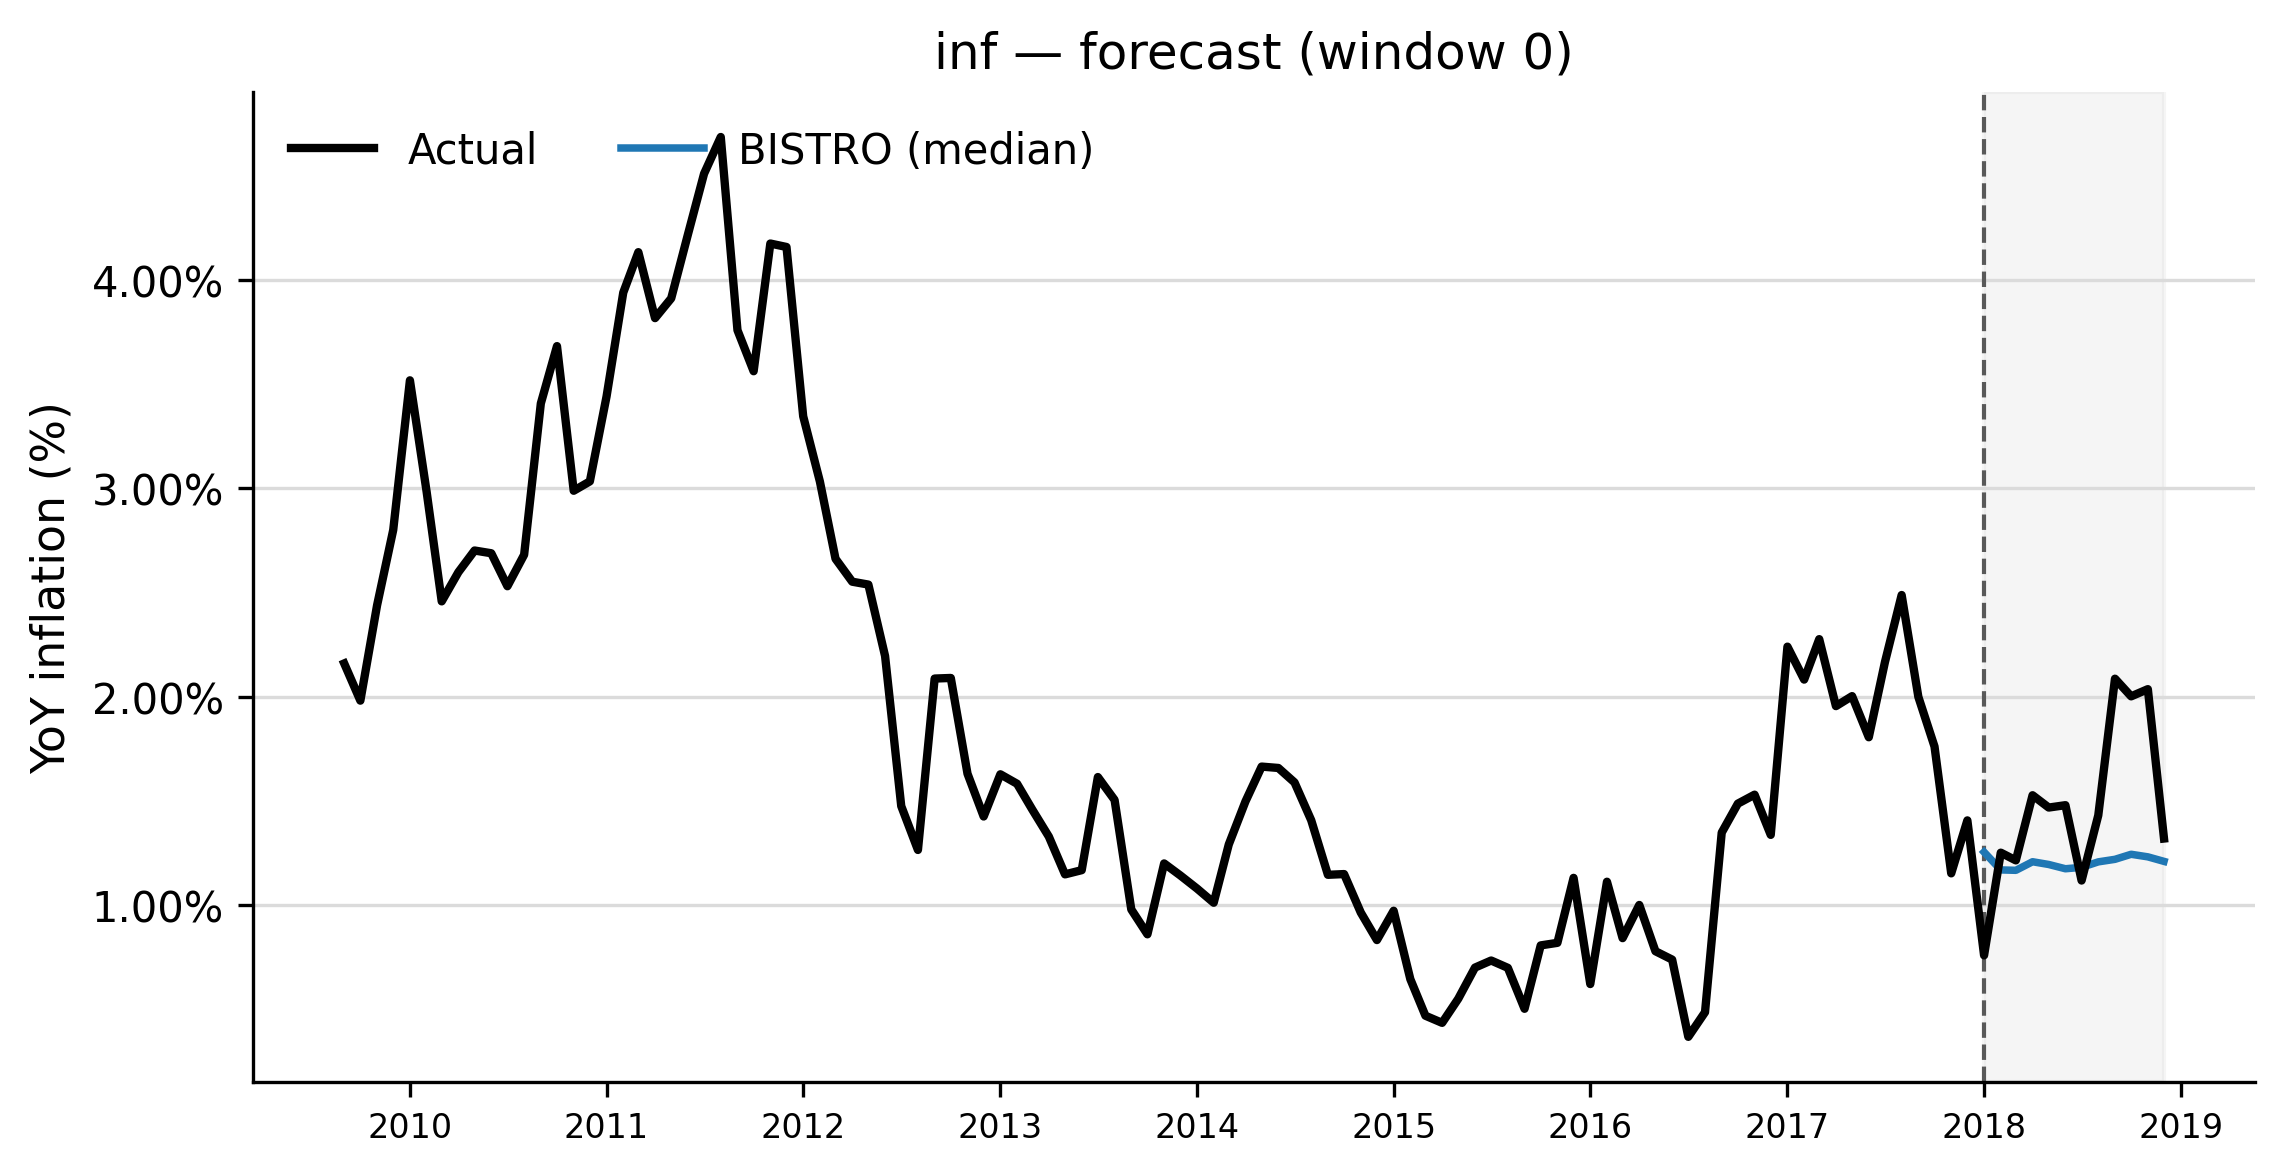

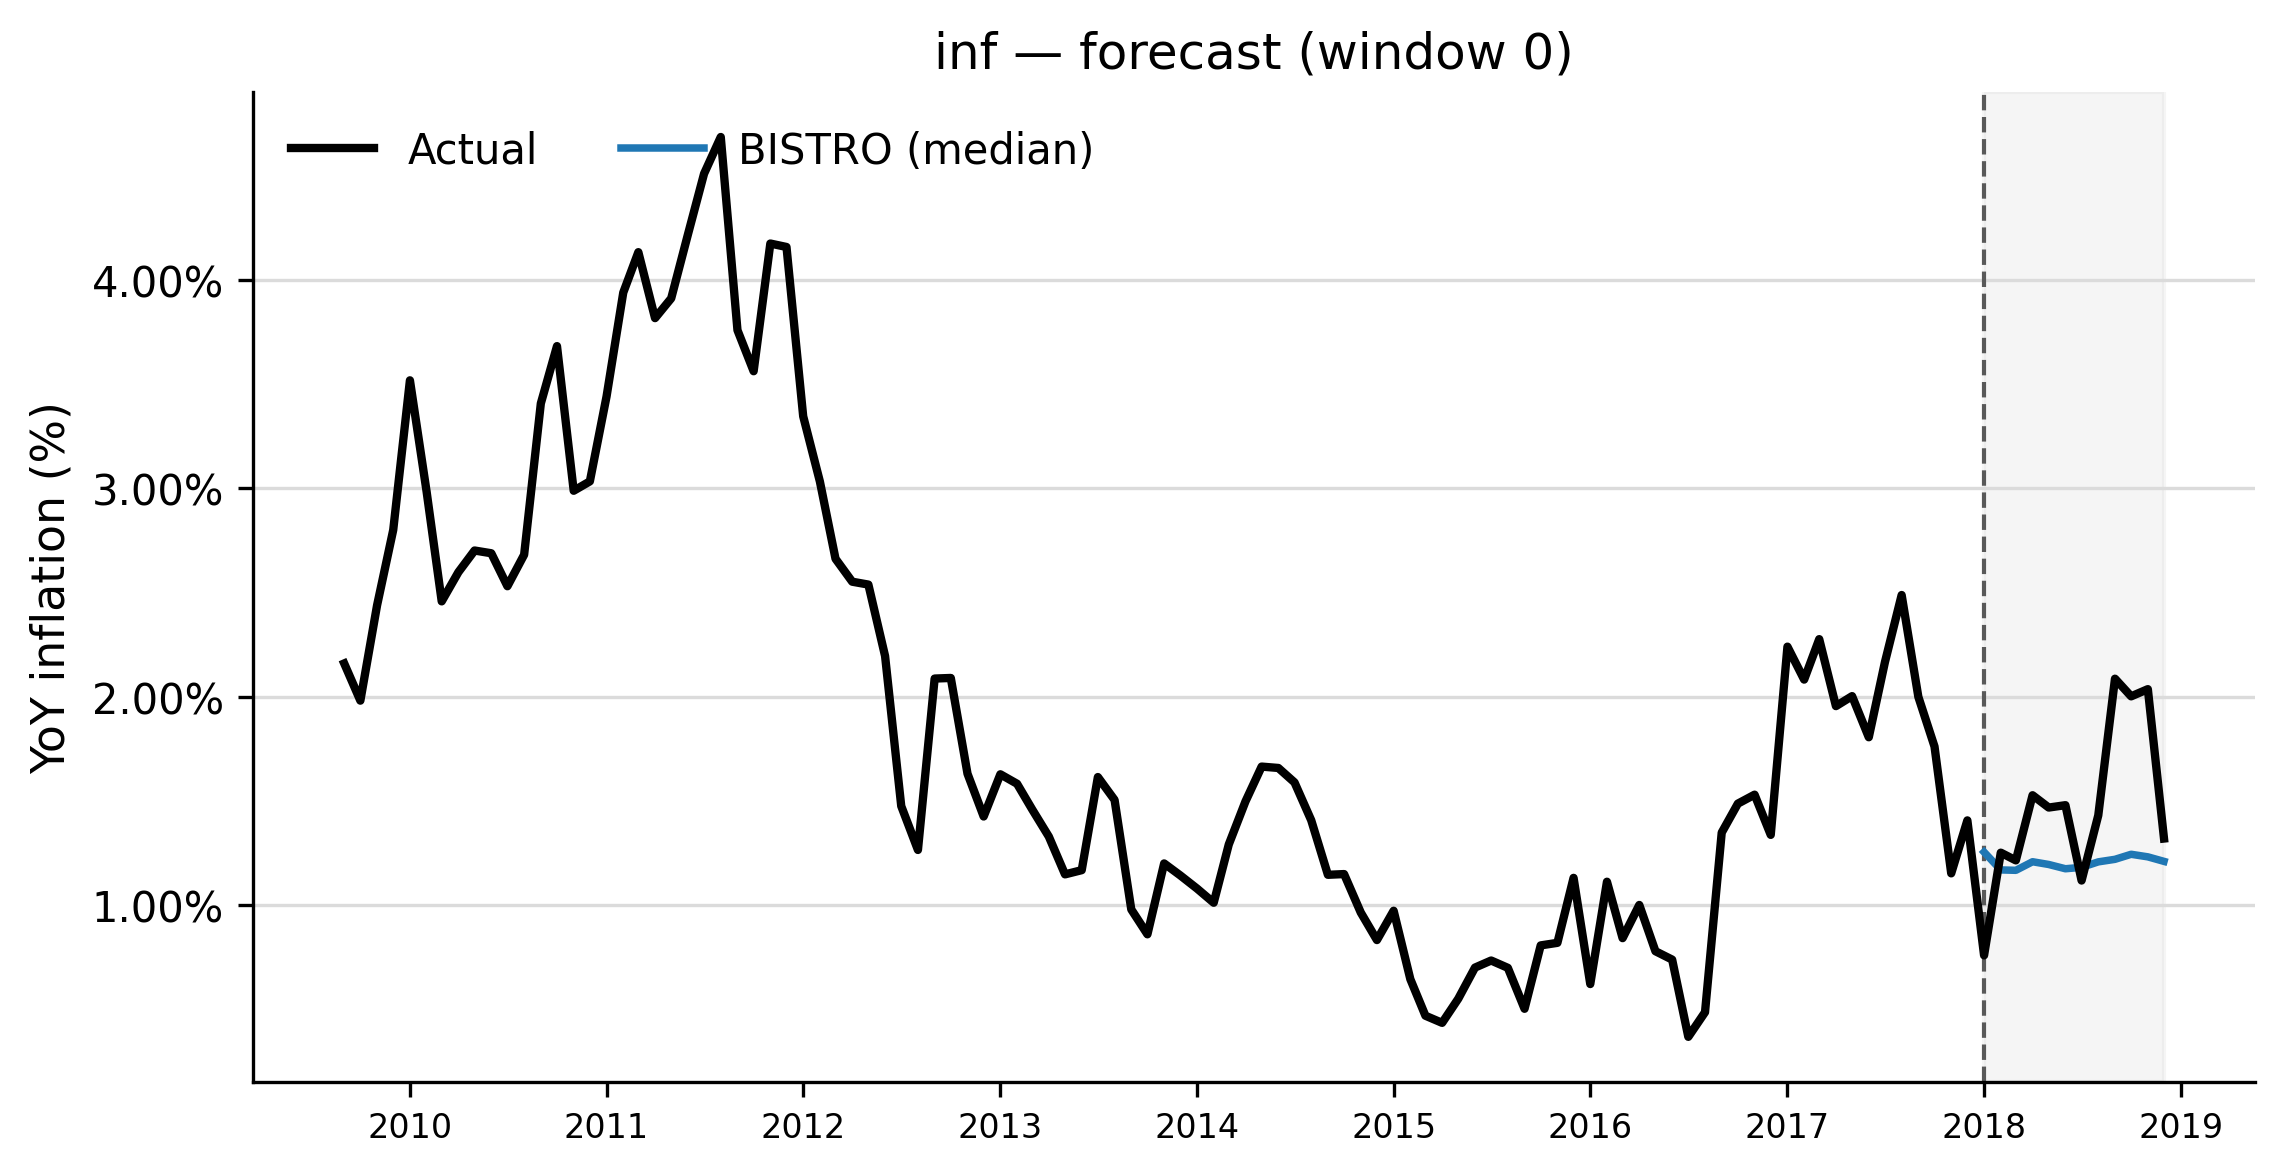

In [45]:
w = 0

df_actual = prep.df_monthly[[target_col]].rename(columns={target_col: "actual"})
df_pred = bistro_monthly_by_window[w]

plot_from = prep.forecast_start - min(CTX, 120)
plot_to = df_pred.index.max()

df_plot = df_actual.join(df_pred[["bistro_pred"]], how="outer").sort_index()
df_plot = df_plot.loc[plot_from:plot_to]

fig, ax = plot_publication_forecast_comparison(
    df_plot,
    actual_col="actual",
    forecast_cols={"bistro_pred": "BISTRO (median)"},
    forecast_start=prep.forecast_start,
    title=f"{target_col} — forecast (window {w})",
    ylabel="YoY inflation (%)",
    y_fmt="percent",
    percent_scale=100.0,
    savepaths=[
        repo_root / "script" / "figures" / "forecast_single_timeseries.png",
    ],
)

fig